In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
%cd '/content/drive/MyDrive/iran-war-risk-replication/'

/content/drive/MyDrive/iran-war-risk-replication


In [7]:
!pip install -r requirements.txt
!pip install -q google-cloud-bigquery db-dtypes pyarrow

In [8]:
from google.colab import auth
auth.authenticate_user()

In [11]:
!python -m src.collect_news \
    --project "" \ #removed project id before commit
    --dry-run

[1/8] 2026-02-28..2026-03-01: 558.37 MB
[2/8] 2026-03-01..2026-04-01: 20.55 GB
[3/8] 2026-04-01..2026-05-01: 19.12 GB
[4/8] 2026-05-01..2026-06-01: 19.26 GB
[5/8] 2026-06-01..2026-07-01: 19.00 GB
[6/8] 2026-07-01..2026-08-01: 19.03 GB
[7/8] 2026-08-01..2026-09-01: 17.94 GB
[8/8] 2026-09-01..2026-09-23: 12.95 GB
Estimated total scanned: 128.40 GB


In [12]:
!python -m src.collect_news \
    --project "" \
    --maximum-bytes-billed 26843545600

[1/8]  12.5% | 2026-02-28..2026-03-01 | 246 articles | queried 558.37 MB | ETA 1.1 min
[2/8]  25.0% | 2026-03-01..2026-04-01 | 9,106 articles | queried 20.55 GB | ETA 1.3 min
[3/8]  37.5% | 2026-04-01..2026-05-01 | 6,515 articles | queried 19.12 GB | ETA 1.1 min
[4/8]  50.0% | 2026-05-01..2026-06-01 | 4,283 articles | queried 19.26 GB | ETA 0.8 min
[5/8]  62.5% | 2026-06-01..2026-07-01 | 3,794 articles | queried 19.00 GB | ETA 0.6 min
[6/8]  75.0% | 2026-07-01..2026-08-01 | 3,298 articles | queried 19.03 GB | ETA 0.4 min
[7/8]  87.5% | 2026-08-01..2026-09-01 | 2,976 articles | queried 17.94 GB | ETA 0.2 min
[8/8] 100.0% | 2026-09-01..2026-09-23 | 2,155 articles | queried 12.95 GB | ETA 0.0 min
Finished: 30,980 unique articles from 10 publications.


In [8]:
import pandas as pd
articles = pd.read_csv("data/raw/articles_raw.csv")

print("Articles:", len(articles))
print("Publications:", articles["publication"].nunique())
display(
    articles.groupby("publication")
    .size()
    .sort_values(ascending=False)
    .rename("article_count")
    .to_frame()
)

Articles: 30980
Publications: 10


,article_count
publication,
CNN,9704
The Guardian,4593
Al-Monitor,4515
BBC,3766
Al Jazeera,3669
CNBC,3102
Reuters,1049
Bloomberg,464
New York Times,117


In [9]:
!python -m src.process_news

Building sparse TF-IDF matrix for 26,734 articles...
TF-IDF shape: 26,734 x 36,040; nonzero values: 708,243
Cluster progress: 10/207 days (4.8%); 502 similarity links
Cluster progress: 20/207 days (9.7%); 894 similarity links
Cluster progress: 30/207 days (14.5%); 1,080 similarity links
Cluster progress: 40/207 days (19.3%); 1,569 similarity links
Cluster progress: 50/207 days (24.2%); 1,929 similarity links
Cluster progress: 60/207 days (29.0%); 2,113 similarity links
Cluster progress: 70/207 days (33.8%); 2,289 similarity links
Cluster progress: 80/207 days (38.6%); 2,385 similarity links
Cluster progress: 90/207 days (43.5%); 2,523 similarity links
Cluster progress: 100/207 days (48.3%); 2,661 similarity links
Cluster progress: 110/207 days (53.1%); 2,980 similarity links
Cluster progress: 120/207 days (58.0%); 3,134 similarity links
Cluster progress: 130/207 days (62.8%); 3,181 similarity links
Cluster progress: 140/207 days (67.6%); 3,348 similarity links
Cluster progress: 150/207

In [10]:
import shutil
import subprocess
from pathlib import Path
import yaml

config_path = Path("config.yaml")
candidate_path = Path(
    "data/processed/candidate_high_news_days.csv"
)
scores_path = Path(
    "data/processed/daily_news_scores.csv"
)

# Load and remember the original threshold.
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

original_percentile = config["news"]["candidate_percentile"]

results = []

try:
    for percentile in [0.75, 0.85]:
        config["news"]["candidate_percentile"] = percentile

        with open(config_path, "w") as f:
            yaml.safe_dump(
                config,
                f,
                sort_keys=False,
            )

        print(f"\nRunning percentile {percentile:.2f}...")

        subprocess.run(
            ["python", "-m", "src.score_news_days"],
            check=True,
        )

        label = str(int(percentile * 100))

        candidate_output = Path(
            f"data/processed/"
            f"candidate_high_news_days_p{label}.csv"
        )
        scores_output = Path(
            f"data/processed/"
            f"daily_news_scores_p{label}.csv"
        )

        shutil.copy2(candidate_path, candidate_output)
        shutil.copy2(scores_path, scores_output)

        candidates = pd.read_csv(candidate_output)
        daily = pd.read_csv(scores_output)

        selected = daily.loc[
            daily["candidate_high"].eq(1)
        ]

        results.append({
            "percentile": percentile,
            "candidate_days": len(candidates),
            "minimum_selected_score": (
                selected["news_intensity_score"].min()
                if not selected.empty
                else None
            ),
            "candidate_file": str(candidate_output),
        })

finally:
    # Restore the original threshold.
    config["news"]["candidate_percentile"] = original_percentile

    with open(config_path, "w") as f:
        yaml.safe_dump(
            config,
            f,
            sort_keys=False,
        )

comparison = pd.DataFrame(results)
display(comparison)


Running percentile 0.75...

Running percentile 0.85...


,percentile,candidate_days,minimum_selected_score,candidate_file
0,0.75,37,0.654554,data/processed/candidate_high_news_days_p75.csv
1,0.85,22,1.017518,data/processed/candidate_high_news_days_p85.csv


In [13]:
!python -m src.score_news_days

Generated 37 candidate H days at cutoff 0.645 (percentile=0.75; global post-onset robust normalization)


In [15]:
path = "data/processed/candidate_high_news_days.csv"
candidates = pd.read_csv(path)

candidates["surprise_confirmed"] = "yes"
candidates["market_attribution_confirmed"] = "yes"
candidates["confounder_review"] = "passed"
candidates["final_include_high"] = 1
candidates["review_notes"] = "All candidates approved under the 0.75 specification."

candidates.to_csv(path, index=False)

print(f"Approved all {len(candidates)} candidate H days.")
display(candidates[[
    "market_date",
    "news_intensity_score",
    "source_group_breadth",
    "final_include_high",
]])

Approved all 37 candidate H days.


,market_date,news_intensity_score,source_group_breadth,final_include_high
0,2026-03-02,3.217584,3,1
1,2026-03-03,1.550733,3,1
2,2026-03-04,1.185037,3,1
3,2026-03-05,1.088401,3,1
4,2026-03-06,1.360930,3,1
5,2026-03-09,2.595581,3,1
6,2026-03-10,1.076628,3,1
7,2026-03-11,0.982690,3,1
8,2026-03-12,0.979746,3,1
9,2026-03-13,1.017518,3,1


In [23]:
!python -m src.promote_news_candidates

Promoted 37 approved news-panel dates


In [24]:
import pandas as pd
from src.build_event_pairs import trading_grid
from src.common import load_config

cfg = load_config()["sample"]
grid = trading_grid(cfg["start"], cfg["end"])
valid_dates = set(pd.to_datetime(grid).normalize())

path = "data/manual/event_candidates.csv"
events = pd.read_csv(path)

event_dates = pd.to_datetime(
    events["effective_trading_date"],
    errors="coerce",
).dt.normalize()

selected = events["include_high"].astype(str).eq("1")
invalid = selected & ~event_dates.isin(valid_dates)

print("Excluded non-trading H dates:")
display(
    events.loc[invalid, [
        "effective_trading_date",
        "event_description",
    ]]
)

events.loc[invalid, "include_high"] = 0
events.loc[invalid, "notes"] = (
    events.loc[invalid, "notes"].fillna("").astype(str)
    + " Excluded: not a U.S. trading day."
)

events.to_csv(path, index=False)

print(f"Excluded {invalid.sum()} non-trading dates.")
print(f"Remaining H days: {(events['include_high'].astype(str) == '1').sum()}")

Excluded non-trading H dates:


,effective_trading_date,event_description
82,2026-05-25,"Oil falls, Asian stocks climb on hopes of US-I..."


Excluded 1 non-trading dates.
Remaining H days: 36


In [25]:
!python -m src.build_event_pairs

Wrote 36 H and 36 L observations
L-day news intensity: median=0.325, max=0.636. Trading-day distance: median=28.0, max=69.


In [26]:
import pandas as pd

pairs = pd.read_csv(
    "data/processed/event_pairs.csv",
    parse_dates=["date"],
)

scores = pd.read_csv(
    "data/processed/daily_news_scores.csv",
    parse_dates=["market_date"],
)

pairs["date"] = pairs["date"].dt.normalize()
scores["market_date"] = scores["market_date"].dt.normalize()

print(pairs.groupby("sample").size())

comparison = (
    pairs.merge(
        scores[["market_date", "news_intensity_score"]],
        left_on="date",
        right_on="market_date",
        how="left",
        validate="many_to_one",
    )
    .groupby("sample")["news_intensity_score"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(comparison)

sample
H    36
L    36
dtype: int64


,count,mean,median,min,max
sample,,,,,
H,36,1.334118,1.089259,0.654554,3.217584
L,36,0.262756,0.325490,-0.235283,0.636369


In [27]:
!python -m src.download_market_data

Wrote 149 daily observations


In [28]:
from src.common import load_config

cfg = load_config()
variables = list(cfg["units"])

pairs_path = "data/processed/event_pairs.csv"
market_path = "data/processed/market_changes.csv"

pairs = pd.read_csv(pairs_path, parse_dates=["date"])
market = pd.read_csv(market_path, parse_dates=["date"])

audit = pairs.merge(
    market,
    on="date",
    how="left",
    validate="one_to_one",
)

audit["missing_variables"] = audit[variables].apply(
    lambda row: ", ".join(row.index[row.isna()]),
    axis=1,
)

incomplete = audit["missing_variables"].ne("")
bad_pair_ids = set(audit.loc[incomplete, "pair_id"])

print("Incomplete event dates:")
display(
    audit.loc[incomplete, [
        "pair_id",
        "sample",
        "date",
        "missing_variables",
    ]].sort_values(["pair_id", "sample"])
)

clean_pairs = pairs.loc[~pairs["pair_id"].isin(bad_pair_ids)].copy()

print(f"Removed {len(bad_pair_ids)} incomplete H/L pairs")
print(clean_pairs.groupby("sample").size())

assert clean_pairs.groupby("sample").size().nunique() == 1
assert not clean_pairs["date"].duplicated().any()

clean_pairs.to_csv(pairs_path, index=False)

Incomplete event dates:


,pair_id,sample,date,missing_variables
0,1,H,2026-03-02,"dgs2, dgs10, breakeven10, liquidity_proxy, sp5..."
40,21,H,2026-04-06,"sp500, oil_front, gold"
55,28,L,2026-06-01,"dgs2, dgs10, breakeven10, liquidity_proxy, sp5..."
63,32,L,2026-05-26,"dgs2, dgs10, breakeven10, liquidity_proxy, sp5..."


Removed 4 incomplete H/L pairs
sample
H    32
L    32
dtype: int64


In [32]:
!python -m src.run_analysis

Estimated 9 outcomes using 31 H/L pairs


In [34]:
df = max(n_h + n_l - 1, 1)

for estimator in ["w1", "w2", "w3"]:
    iv[f"{estimator}_p"] = (
        2 * stats.t.sf(
            np.abs(iv[f"{estimator}_t"]),
            df=df,
        )
    )

main_results = iv[[
    "variable",
    "units",
    "w1_beta",
    "w1_t",
    "w1_p",
    "w2_beta",
    "w2_t",
    "w2_p",
    "w3_beta",
    "w3_se",
    "w3_t",
    "w3_p",
    "w3_effect_comparison_move",
    "w3_effect_one_sd",
]].copy()

display(main_results.round(4))

,variable,units,w1_beta,w1_t,w1_p,w2_beta,w2_t,w2_p,w3_beta,w3_se,w3_t,w3_p,w3_effect_comparison_move,w3_effect_one_sd
0,dgs10,pp_change,0.7826,0.9167,0.3629,1.7111,0.8223,0.4141,0.8616,0.8691,0.9914,0.3254,-0.2154,0.0166
1,breakeven10,pp_change,0.7652,0.6461,0.5206,-0.2614,-0.4343,0.6656,-0.1064,0.4899,-0.2171,0.8289,0.0266,-0.0020
2,liquidity_proxy,pp_change,1.1217,0.9612,0.3402,0.6899,0.8427,0.4027,0.7502,0.8133,0.9224,0.3599,-0.1875,0.0144
3,sp500,pct_change,-50.8226,-0.6601,0.5117,-31.3454,-2.0655,0.0431,-31.0045,15.0048,-2.0663,0.0431,7.7511,-0.5972
4,bbb_spread,pp_change,-0.1739,-0.3626,0.7181,-3.1000,-0.4016,0.6894,-0.9252,1.3438,-0.6885,0.4938,0.2313,-0.0178
5,hy_spread,pp_change,1.2783,0.4248,0.6725,9.7347,0.6562,0.5142,5.8299,6.2085,0.9390,0.3514,-1.4575,0.1123
6,oil_front,dollar_change,253.0696,0.6445,0.5217,302.9967,1.6796,0.0981,301.3397,178.8058,1.6853,0.0970,-75.3349,5.8040
7,gold,dollar_change,-4145.5719,-0.6606,0.5114,-3665.9469,-1.6622,0.1016,-3672.9586,2208.2545,-1.6633,0.1014,918.2396,-70.7431
8,broad_dollar,pct_change,8.5107,0.6025,0.5491,30.7535,0.9118,0.3655,24.9605,25.2304,0.9893,0.3264,-6.2401,0.4808


In [35]:
summary = iv[[
    "variable",
    "units",
    "w3_beta",
    "w3_se",
    "w3_t",
    "w3_p",
    "w3_effect_comparison_move",
    "w3_effect_one_sd",
]].copy()

summary["significant_10pct"] = summary["w3_p"] < 0.10
summary["significant_5pct"] = summary["w3_p"] < 0.05
summary["significant_1pct"] = summary["w3_p"] < 0.01

summary = summary.sort_values("w3_p")

display(summary.round(4))

,variable,units,w3_beta,w3_se,w3_t,w3_p,w3_effect_comparison_move,w3_effect_one_sd,significant_10pct,significant_5pct,significant_1pct
3,sp500,pct_change,-31.0045,15.0048,-2.0663,0.0431,7.7511,-0.5972,True,True,False
6,oil_front,dollar_change,301.3397,178.8058,1.6853,0.0970,-75.3349,5.8040,True,False,False
7,gold,dollar_change,-3672.9586,2208.2545,-1.6633,0.1014,918.2396,-70.7431,False,False,False
0,dgs10,pp_change,0.8616,0.8691,0.9914,0.3254,-0.2154,0.0166,False,False,False
8,broad_dollar,pct_change,24.9605,25.2304,0.9893,0.3264,-6.2401,0.4808,False,False,False
5,hy_spread,pp_change,5.8299,6.2085,0.9390,0.3514,-1.4575,0.1123,False,False,False
2,liquidity_proxy,pp_change,0.7502,0.8133,0.9224,0.3599,-0.1875,0.0144,False,False,False
4,bbb_spread,pp_change,-0.9252,1.3438,-0.6885,0.4938,0.2313,-0.0178,False,False,False
1,breakeven10,pp_change,-0.1064,0.4899,-0.2171,0.8289,0.0266,-0.0020,False,False,False


In [36]:
import pandas as pd
import numpy as np

sample = pd.read_csv(
    "outputs/event_sample_audit.csv",
    parse_dates=["date"],
)

variables = [
    "dgs2",
    "dgs10",
    "breakeven10",
    "liquidity_proxy",
    "sp500",
    "bbb_spread",
    "hy_spread",
    "oil_front",
    "gold",
    "broad_dollar",
]

rows = []

for variable in variables:
    h = sample.loc[sample["sample"] == "H", variable].dropna()
    l = sample.loc[sample["sample"] == "L", variable].dropna()

    h_variance = h.var(ddof=1)
    l_variance = l.var(ddof=1)

    rows.append({
        "variable": variable,
        "n_H": len(h),
        "n_L": len(l),
        "H_volatility_sd": h.std(ddof=1),
        "L_volatility_sd": l.std(ddof=1),
        "H_variance": h_variance,
        "L_variance": l_variance,
        "variance_difference_H_minus_L": h_variance - l_variance,
        "variance_ratio_H_over_L": (
            h_variance / l_variance if l_variance > 0 else np.nan
        ),
    })

volatility = pd.DataFrame(rows)

display(
    volatility.sort_values(
        "variance_ratio_H_over_L",
        ascending=False,
    ).round(4)
)

,variable,n_H,n_L,H_volatility_sd,L_volatility_sd,H_variance,L_variance,variance_difference_H_minus_L,variance_ratio_H_over_L
6,hy_spread,31,31,0.0750,0.0305,0.0056,0.0009,0.0047,6.0346
7,oil_front,31,31,6.1253,2.8872,37.5191,8.3360,29.1831,4.5009
5,bbb_spread,31,31,0.0166,0.0086,0.0003,0.0001,0.0002,3.7654
9,broad_dollar,31,31,0.3708,0.1936,0.1375,0.0375,0.1000,3.6684
4,sp500,31,31,0.9650,0.5638,0.9313,0.3179,0.6134,2.9293
8,gold,31,31,95.0364,60.1036,9031.9167,3612.4392,5419.4775,2.5002
1,dgs10,31,31,0.0469,0.0403,0.0022,0.0016,0.0006,1.3526
0,dgs2,31,31,0.0508,0.0444,0.0026,0.0020,0.0006,1.3111
3,liquidity_proxy,31,31,0.0469,0.0440,0.0022,0.0019,0.0003,1.1376
2,breakeven10,31,31,0.0220,0.0234,0.0005,0.0005,-0.0001,0.8782


In [37]:
from scipy.stats import levene
import pandas as pd

rows = []

for variable in variables:
    h = sample.loc[sample["sample"] == "H", variable].dropna()
    l = sample.loc[sample["sample"] == "L", variable].dropna()

    statistic, p_value = levene(h, l, center="median")

    rows.append({
        "variable": variable,
        "H_sd": h.std(ddof=1),
        "L_sd": l.std(ddof=1),
        "variance_ratio": h.var(ddof=1) / l.var(ddof=1),
        "brown_forsythe_stat": statistic,
        "p_value": p_value,
        "significant_10pct": p_value < 0.10,
        "significant_5pct": p_value < 0.05,
    })

variance_tests = pd.DataFrame(rows).sort_values("p_value")

display(variance_tests.round(4))

,variable,H_sd,L_sd,variance_ratio,brown_forsythe_stat,p_value,significant_10pct,significant_5pct
9,broad_dollar,0.3708,0.1936,3.6684,7.7928,0.0070,True,True
4,sp500,0.9650,0.5638,2.9293,7.2281,0.0093,True,True
6,hy_spread,0.0750,0.0305,6.0346,7.2038,0.0094,True,True
5,bbb_spread,0.0166,0.0086,3.7654,6.7406,0.0118,True,True
7,oil_front,6.1253,2.8872,4.5009,5.0655,0.0281,True,True
8,gold,95.0364,60.1036,2.5002,2.8547,0.0963,True,False
0,dgs2,0.0508,0.0444,1.3111,0.5921,0.4446,False,False
1,dgs10,0.0469,0.0403,1.3526,0.1091,0.7423,False,False
2,breakeven10,0.0220,0.0234,0.8782,0.0718,0.7896,False,False
3,liquidity_proxy,0.0469,0.0440,1.1376,0.0000,1.0000,False,False


In [38]:
rows = []

for variable in variables:
    h = sample.loc[sample["sample"] == "H", variable].dropna()
    l = sample.loc[sample["sample"] == "L", variable].dropna()

    rows.append({
        "variable": variable,
        "H_mean": h.mean(),
        "L_mean": l.mean(),
        "centered_variance_difference": (
            h.var(ddof=0) - l.var(ddof=0)
        ),
        "second_moment_difference": (
            np.mean(h**2) - np.mean(l**2)
        ),
    })

moment_check = pd.DataFrame(rows)
display(moment_check.round(6))

,variable,H_mean,L_mean,centered_variance_difference,second_moment_difference
0,dgs2,0.006129,0.016129,0.000594,0.000371
1,dgs10,0.010000,0.012581,0.000555,0.000497
2,breakeven10,0.000968,0.003226,-0.000065,-0.000074
3,liquidity_proxy,0.010000,0.008387,0.000257,0.000287
4,sp500,-0.036595,0.062954,0.593595,0.590971
5,bbb_spread,0.001935,-0.000000,0.000196,0.000200
6,hy_spread,0.009677,-0.004194,0.004540,0.004616
7,oil_front,0.500645,0.216452,28.241738,28.445532
8,gold,-20.532274,-5.335489,5244.655598,5637.762428
9,broad_dollar,0.025367,-0.018898,0.096809,0.097095


In [72]:
labels = {
    "dgs10": "Ten-year Treasury yield",
    "breakeven10": "Break-even inflation",
    "liquidity_proxy": "Treasury liquidity proxy",
    "sp500": "S&P 500",
    "bbb_spread": "BBB yield spread",
    "hy_spread": "High-yield spread",
    "oil_front": "Oil price",
    "gold": "Gold price",
    "broad_dollar": "Broad dollar",
}

unit_labels = {
    "pp_change": "Percentage-point change",
    "pct_change": "Percent change",
    "dollar_change": "Dollar change",
}

table_2 = iv.copy()

table_2["Variable"] = table_2["variable"].map(labels)
table_2["Units"] = table_2["units"].map(unit_labels)

table_2["W1 estimate"] = table_2["w1_beta"]
table_2["W1 |t|"] = table_2["w1_t"].abs()

table_2["W2 estimate"] = table_2["w2_beta"]
table_2["W2 |t|"] = table_2["w2_t"].abs()

table_2["W3 estimate"] = table_2["w3_beta"]
table_2["W3 |t|"] = table_2["w3_t"].abs()

table_2["W3 effect: 25-bp DGS2 decline"] = (
    table_2["w3_effect_comparison_move"]
)

table_2["W3 effect: one-SD DGS2 shock"] = (
    table_2["w3_effect_one_sd"]
)

table_2 = table_2[[
    "Variable",
    "Units",
    "W1 estimate",
    "W1 |t|",
    "W2 estimate",
    "W2 |t|",
    "W3 estimate",
    "W3 |t|",
    "W3 effect: 25-bp DGS2 decline",
    "W3 effect: one-SD DGS2 shock",
]]

table_2.to_csv(
    table_dir / "table_2_iv_estimates_formatted.csv",
    index=False,
)

display(table_2.round(4))

,Variable,Units,W1 estimate,W1 |t|,W2 estimate,W2 |t|,W3 estimate,W3 |t|,W3 effect: 25-bp DGS2 decline,W3 effect: one-SD DGS2 shock
0,Ten-year Treasury yield,Percentage-point change,0.4579,0.4172,1.1020,0.4737,0.2365,0.2038,-0.0591,0.0043
1,Break-even inflation,Percentage-point change,-0.2710,0.2395,0.4828,0.3736,-0.0184,0.0389,0.0046,-0.0003
2,Treasury liquidity proxy,Percentage-point change,0.8224,0.7517,-0.1250,0.0576,0.6617,0.6109,-0.1654,0.0121
3,S&P 500,Percent change,-46.5055,0.6266,-30.5811,1.6321,-30.6369,1.6325,7.6592,-0.5602
4,BBB yield spread,Percentage-point change,-0.1308,0.2816,-4.2143,0.3006,-0.8340,0.6203,0.2085,-0.0153
5,High-yield spread,Percentage-point change,1.6542,0.4514,7.7627,0.8106,5.6469,1.0390,-1.4117,0.1033
6,Oil price,Dollar change,202.4954,0.6238,471.7178,1.3383,458.5223,1.3463,-114.6306,8.3845
7,Gold price,Dollar change,-6808.5150,0.6098,-2416.0667,2.2671,-2356.9473,2.2550,589.2368,-43.0990
8,Broad dollar,Percent change,12.7697,0.5896,18.1153,1.2636,17.5563,1.2933,-4.3891,0.3210


In [74]:
table_3 = variance.copy()

table_3["Variable"] = table_3["variable"].map(labels)
table_3["H/L variance ratio"] = (
    table_3["var_h"] / table_3["var_l"]
)

table_3 = table_3.rename(columns={
    "var_l": "Variance on L days",
    "var_h": "Variance on H days",
    "predicted_change": "War-factor predicted variance change",
    "pct_explained_h_lower_bound":
        "Lower-bound % of H variance explained",
    "pct_explained_paired_period":
        "% of complete-period variance explained",
})

table_3 = table_3[[
    "Variable",
    "Variance on L days",
    "Variance on H days",
    "H/L variance ratio",
    "War-factor predicted variance change",
    "Lower-bound % of H variance explained",
    "% of complete-period variance explained",
]]

table_3.to_csv(
    table_dir / "table_3_variance_decomposition_formatted.csv",
    index=False,
)

display(table_3.round(4))

,Variable,Variance on L days,Variance on H days,H/L variance ratio,War-factor predicted variance change,Lower-bound % of H variance explained,% of complete-period variance explained
0,Ten-year Treasury yield,0.0020,0.0021,1.0859,0.0000,0.8760,0.4560
1,Break-even inflation,0.0005,0.0005,0.9152,0.0000,0.0240,0.0114
2,Treasury liquidity proxy,0.0022,0.0021,0.9841,0.0001,6.8585,3.4018
3,S&P 500,0.4549,0.9304,2.0454,0.3139,33.7312,22.6551
4,BBB yield spread,0.0001,0.0002,4.2778,0.0002,96.6559,78.3422
5,High-yield spread,0.0009,0.0052,5.8211,0.0107,205.6644,175.5130
6,Oil price,3.8492,35.7889,9.2978,70.2999,196.4292,177.3543
7,Gold price,3753.2756,9253.6862,2.4655,1857.5202,20.0733,14.2810
8,Broad dollar,0.0457,0.1230,2.6942,0.1031,83.7862,61.1059


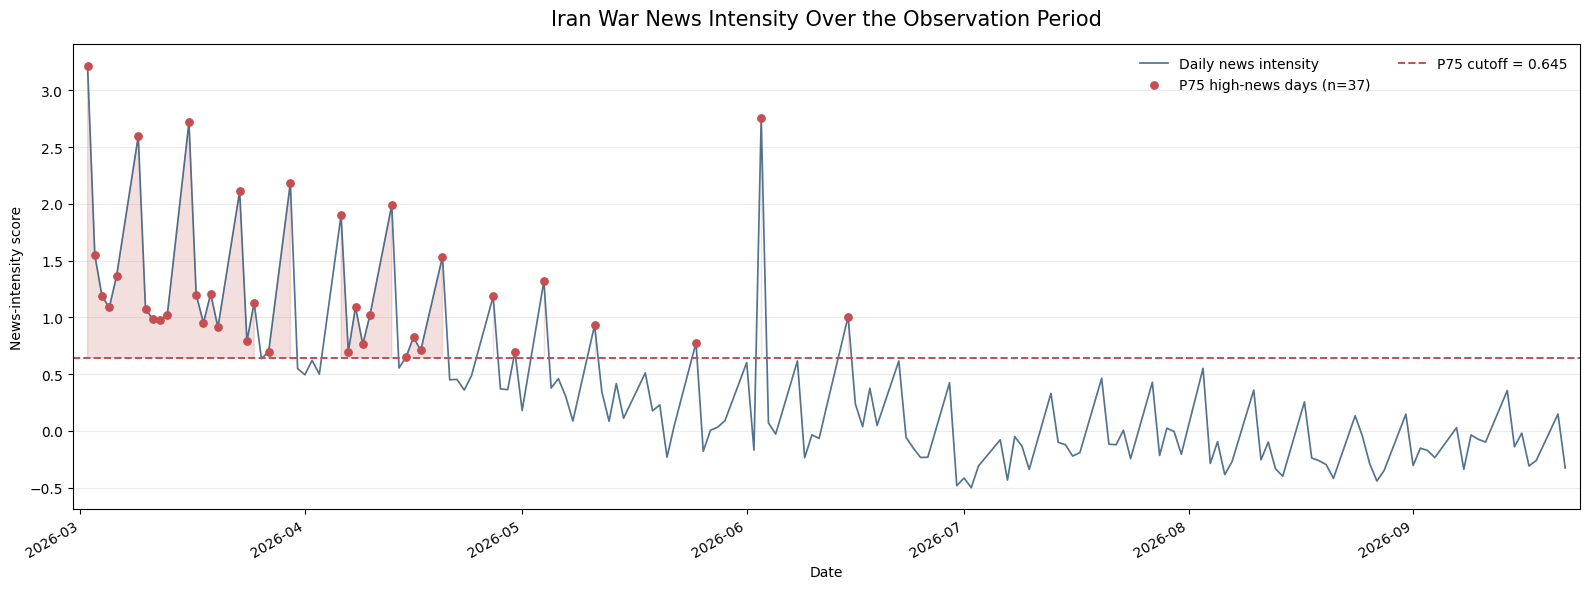

Observation period: 2026-03-02 to 2026-09-22
Number of daily observations: 147
P75 cutoff: 0.6455
Days at or above cutoff: 37


In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Set project directory
# ------------------------------------------------------------
PROJECT_DIR = Path(
    "/content/drive/MyDrive/iran-war-risk-replication"
)

# Change this only if your daily-score file has a different name
SCORES_FILE = PROJECT_DIR / "data/processed/daily_news_scores.csv"

# ------------------------------------------------------------
# 2. Load and prepare daily scores
# ------------------------------------------------------------
scores = pd.read_csv(SCORES_FILE)

# Support either possible date-column name
date_col = (
    "market_date"
    if "market_date" in scores.columns
    else "date"
)

scores[date_col] = pd.to_datetime(scores[date_col])
scores["news_intensity_score"] = pd.to_numeric(
    scores["news_intensity_score"],
    errors="coerce"
)

scores = (
    scores.dropna(subset=[date_col, "news_intensity_score"])
          .sort_values(date_col)
          .drop_duplicates(date_col)
          .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Calculate P75 cutoff
# ------------------------------------------------------------
threshold = scores["news_intensity_score"].quantile(0.75)
scores["high_news_day"] = (
    scores["news_intensity_score"] >= threshold
)

# ------------------------------------------------------------
# 4. Plot full observation period
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 6))

# Daily intensity line
ax.plot(
    scores[date_col],
    scores["news_intensity_score"],
    color="#355C7D",
    linewidth=1.25,
    alpha=0.85,
    label="Daily news intensity"
)

# Shade area under the line
ax.fill_between(
    scores[date_col],
    scores["news_intensity_score"],
    threshold,
    where=scores["high_news_day"],
    color="#C44E52",
    alpha=0.18
)

# Mark P75 high-news observations
high = scores.loc[scores["high_news_day"]]

ax.scatter(
    high[date_col],
    high["news_intensity_score"],
    color="#C44E52",
    s=28,
    zorder=3,
    label=f"P75 high-news days (n={len(high)})"
)

# P75 cutoff
ax.axhline(
    threshold,
    color="#C44E52",
    linestyle="--",
    linewidth=1.4,
    label=f"P75 cutoff = {threshold:.3f}"
)

# War-period starting boundary
sample_start = pd.Timestamp("2026-02-28")

if scores[date_col].min() <= sample_start <= scores[date_col].max():
    ax.axvline(
        sample_start,
        color="black",
        linestyle=":",
        linewidth=1.2,
        label="Sample begins: Feb. 28, 2026"
    )

# ------------------------------------------------------------
# 5. Formatting
# ------------------------------------------------------------
ax.set_title(
    "Iran War News Intensity Over the Observation Period",
    fontsize=15,
    pad=14
)
ax.set_xlabel("Date")
ax.set_ylabel("News-intensity score")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=2)
ax.margins(x=0.01)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Observation period: {scores[date_col].min().date()} to "
      f"{scores[date_col].max().date()}")
print(f"Number of daily observations: {len(scores)}")
print(f"P75 cutoff: {threshold:.4f}")
print(f"Days at or above cutoff: {scores['high_news_day'].sum()}")

News scores: /content/drive/MyDrive/iran-war-risk-replication/data/processed/daily_news_scores.csv
Market data: /content/drive/MyDrive/iran-war-risk-replication/data/processed/market_changes.csv

Event classifications:
event_classification
Escalation       21
De-escalation     9
Mixed             7
Name: count, dtype: int64

Market variables:
['dgs2', 'dgs10', 'breakeven10', 'liquidity_proxy', 'sp500', 'bbb_spread', 'hy_spread', 'oil_front', 'gold', 'broad_dollar']

Running baseline specification...

Running controlled specification...

Running clean specification...
Running signed-shock baseline specification...
Running signed-shock controlled specification...
Running signed-shock clean specification...

CONTROLLED SAME-DAY EFFECTS


,variable,units,beta_deescalation_shock,beta_escalation_shock,beta_mixed_shock,se_hac_deescalation_shock,se_hac_escalation_shock,se_hac_mixed_shock,t_stat_deescalation_shock,t_stat_escalation_shock,t_stat_mixed_shock,p_value_deescalation_shock,p_value_escalation_shock,p_value_mixed_shock
0,bbb_spread,pp change,-0.0042,0.0020,0.0005,0.0038,0.0013,0.0017,-1.1211,1.5203,0.2704,0.2622,0.1284,0.7868
1,breakeven10,pp change,-0.0083,-0.0002,0.0009,0.0059,0.0027,0.0031,-1.3988,-0.0561,0.3054,0.1619,0.9552,0.7601
2,broad_dollar,percent change,-0.1093,0.0148,-0.0129,0.1261,0.0351,0.0389,-0.8671,0.4224,-0.3313,0.3859,0.6727,0.7404
3,dgs10,pp change,-0.0037,-0.0005,-0.0077,0.0170,0.0057,0.0048,-0.2174,-0.0858,-1.6064,0.8279,0.9316,0.1082
4,dgs2,pp change,-0.0201,0.0007,-0.0111,0.0160,0.0058,0.0050,-1.2548,0.1297,-2.2285,0.2095,0.8968,0.0258
5,gold,dollar change,47.4507,-14.6460,-15.3796,16.3906,9.9343,6.8565,2.8950,-1.4743,-2.2431,0.0038,0.1404,0.0249
6,hy_spread,pp change,-0.0097,0.0062,0.0047,0.0219,0.0062,0.0070,-0.4426,1.0013,0.6720,0.6580,0.3167,0.5016
7,liquidity_proxy,pp change,0.0018,0.0010,-0.0067,0.0175,0.0059,0.0048,0.1030,0.1605,-1.4112,0.9180,0.8725,0.1582
8,oil_front,dollar change,-2.6815,0.4736,0.0266,2.2530,0.6056,0.8321,-1.1902,0.7820,0.0320,0.2340,0.4342,0.9745
9,sp500,percent change,0.3507,-0.0866,0.0577,0.4198,0.0907,0.1155,0.8353,-0.9541,0.4999,0.4035,0.3401,0.6171



CONTROLLED FIVE-DAY CUMULATIVE EFFECTS


,variable,units,beta_deescalation_shock,beta_escalation_shock,beta_mixed_shock,se_hac_deescalation_shock,se_hac_escalation_shock,se_hac_mixed_shock,t_stat_deescalation_shock,t_stat_escalation_shock,t_stat_mixed_shock,p_value_deescalation_shock,p_value_escalation_shock,p_value_mixed_shock
0,bbb_spread,pp change,-0.0079,0.0095,-0.0118,0.0092,0.0099,0.0033,-0.8630,0.9590,-3.6173,0.3881,0.3375,0.0003
1,breakeven10,pp change,-0.0152,0.0008,-0.0013,0.0146,0.0084,0.0088,-1.0371,0.0911,-0.1418,0.2997,0.9274,0.8873
2,broad_dollar,percent change,-0.0544,0.1854,-0.0950,0.2828,0.0829,0.1267,-0.1924,2.2356,-0.7494,0.8474,0.0254,0.4536
3,dgs10,pp change,-0.0464,0.0207,0.0021,0.0203,0.0113,0.0168,-2.2819,1.8270,0.1235,0.0225,0.0677,0.9017
4,dgs2,pp change,-0.0778,0.0232,-0.0047,0.0229,0.0160,0.0225,-3.4001,1.4485,-0.2076,0.0007,0.1475,0.8356
5,gold,dollar change,105.1779,-92.8153,-143.3484,67.7433,31.5663,57.4425,1.5526,-2.9403,-2.4955,0.1205,0.0033,0.0126
6,hy_spread,pp change,-0.0264,0.0218,-0.0192,0.0342,0.0207,0.0150,-0.7711,1.0486,-1.2781,0.4406,0.2944,0.2012
7,liquidity_proxy,pp change,-0.0459,0.0207,0.0089,0.0291,0.0144,0.0178,-1.5741,1.4395,0.5001,0.1155,0.1500,0.6170
8,oil_front,dollar change,-2.4938,0.6888,-1.7370,2.9071,1.4720,1.1054,-0.8578,0.4680,-1.5713,0.3910,0.6398,0.1161
9,sp500,percent change,0.5941,-0.7510,-0.1015,0.9155,0.3232,0.5327,0.6490,-2.3240,-0.1905,0.5164,0.0201,0.8489



SAME-DAY SPECIFICATION COMPARISON


,variable,units,regressor,beta_baseline,beta_clean,beta_controlled,p_value_baseline,p_value_clean,p_value_controlled
0,bbb_spread,pp change,deescalation_shock,-0.0056,-0.0021,-0.0042,0.1509,0.5983,0.2622
1,bbb_spread,pp change,escalation_shock,0.0024,0.0016,0.0020,0.0725,0.2182,0.1284
2,breakeven10,pp change,deescalation_shock,-0.0089,-0.0055,-0.0083,0.1382,0.3401,0.1619
3,breakeven10,pp change,escalation_shock,0.0002,-0.0027,-0.0002,0.9429,0.3043,0.9552
4,broad_dollar,percent change,deescalation_shock,-0.1130,0.0213,-0.1093,0.3733,0.7595,0.3859
5,broad_dollar,percent change,escalation_shock,0.0322,0.0137,0.0148,0.3094,0.7117,0.6727
6,dgs10,pp change,deescalation_shock,-0.0025,0.0015,-0.0037,0.8892,0.9399,0.8279
7,dgs10,pp change,escalation_shock,-0.0018,-0.0027,-0.0005,0.7418,0.6529,0.9316
8,dgs2,pp change,deescalation_shock,-0.0179,-0.0169,-0.0201,0.2328,0.3486,0.2095
9,dgs2,pp change,escalation_shock,0.0003,-0.0025,0.0007,0.9499,0.6528,0.8968


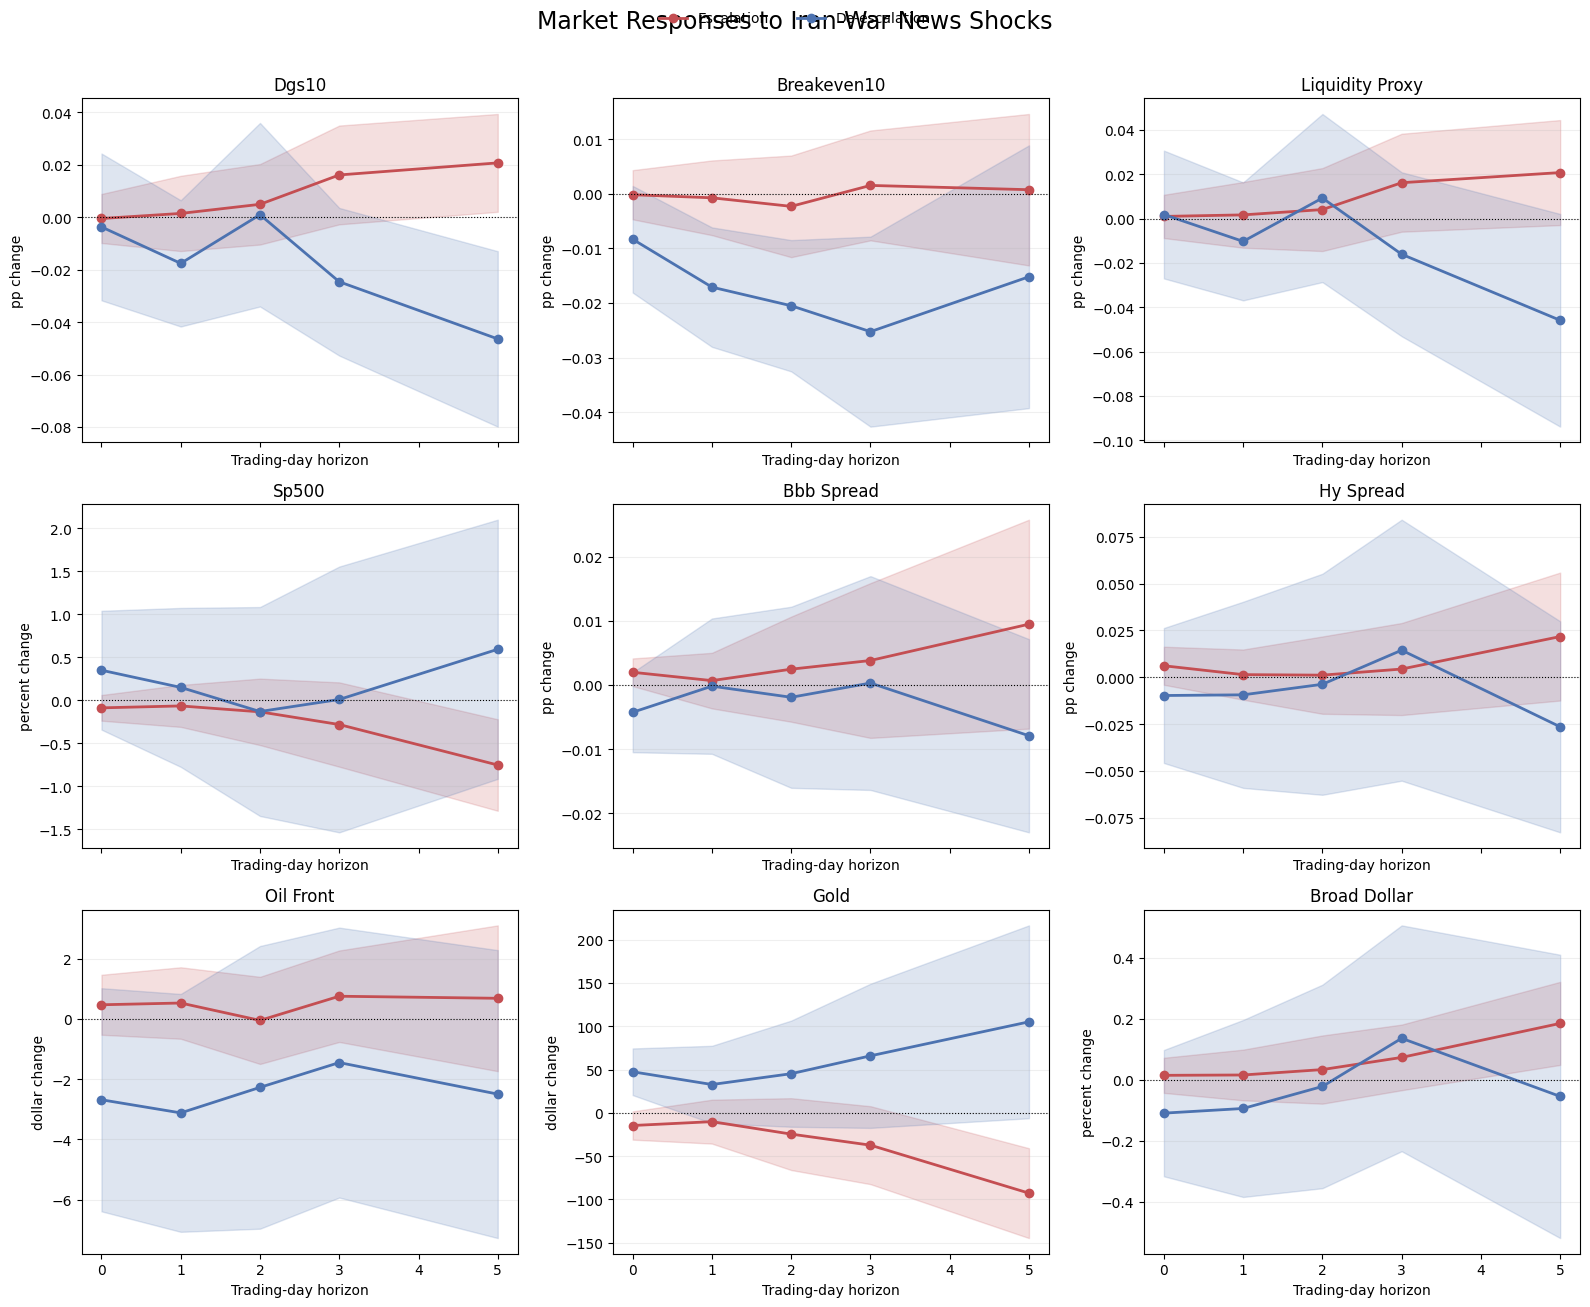


Analysis complete.
Outputs saved to:
/content/drive/MyDrive/iran-war-risk-replication/outputs/signed_local_projections

Main files:
 - classified_event_sample.csv
 - five_day_controlled_effects.csv
 - local_projection_results.csv
 - same_day_controlled_effects.csv
 - same_day_specification_comparison.csv
 - signed_shock_robustness_results.csv
 - signed_war_news_impulse_responses.png


In [4]:
# ============================================================
# SIGNED WAR-NEWS LOCAL PROJECTIONS — COMPLETE IMPLEMENTATION
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/iran-war-risk-replication"
)

OUTPUT_DIR = PROJECT_DIR / "outputs" / "signed_local_projections"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Update these only if your filenames differ
SCORES_CANDIDATES = [
    PROJECT_DIR / "data/processed/daily_news_scores.csv",
    PROJECT_DIR / "data/processed/news_daily_scores.csv",
    PROJECT_DIR / "outputs/daily_news_scores.csv",
]

MARKET_CANDIDATES = [
    PROJECT_DIR / "data/processed/market_data_daily.csv",
    PROJECT_DIR / "data/processed/daily_market_data.csv",
    PROJECT_DIR / "data/processed/market_changes.csv",
    PROJECT_DIR / "outputs/market_data_daily.csv",
]


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


SCORES_FILE = first_existing(SCORES_CANDIDATES)
MARKET_FILE = first_existing(MARKET_CANDIDATES)

if SCORES_FILE is None:
    raise FileNotFoundError(
        "Could not locate daily_news_scores.csv. "
        "Update SCORES_CANDIDATES."
    )

if MARKET_FILE is None:
    raise FileNotFoundError(
        "Could not locate the daily market-data file. "
        "Update MARKET_CANDIDATES."
    )

print("News scores:", SCORES_FILE)
print("Market data:", MARKET_FILE)

# ------------------------------------------------------------
# 2. Load datasets
# ------------------------------------------------------------

scores = pd.read_csv(SCORES_FILE)
market = pd.read_csv(MARKET_FILE)

score_date_col = (
    "market_date"
    if "market_date" in scores.columns
    else "date"
)

market_date_col = (
    "market_date"
    if "market_date" in market.columns
    else "date"
)

scores[score_date_col] = pd.to_datetime(
    scores[score_date_col],
    errors="coerce"
).dt.normalize()

market[market_date_col] = pd.to_datetime(
    market[market_date_col],
    errors="coerce"
).dt.normalize()

scores = scores.rename(
    columns={score_date_col: "market_date"}
)

market = market.rename(
    columns={market_date_col: "market_date"}
)

# Avoid duplicate date columns after merge
scores = (
    scores.sort_values("market_date")
          .drop_duplicates("market_date", keep="last")
)

market = (
    market.sort_values("market_date")
          .drop_duplicates("market_date", keep="last")
)

if "news_intensity_score" not in scores.columns:
    raise ValueError(
        "news_intensity_score is missing from the daily-score file."
    )

scores["news_intensity_score"] = pd.to_numeric(
    scores["news_intensity_score"],
    errors="coerce"
)

# ------------------------------------------------------------
# 3. Manual classification of the 37 P75 dates
# ------------------------------------------------------------

event_classification = {
    # Escalation
    "2026-03-02": "Escalation",
    "2026-03-03": "Escalation",
    "2026-03-04": "Escalation",
    "2026-03-05": "Escalation",
    "2026-03-06": "Escalation",
    "2026-03-09": "Escalation",
    "2026-03-10": "Escalation",
    "2026-03-11": "Escalation",
    "2026-03-12": "Escalation",
    "2026-03-17": "Escalation",
    "2026-03-19": "Escalation",
    "2026-03-23": "Escalation",
    "2026-03-30": "Escalation",
    "2026-04-09": "Escalation",
    "2026-04-10": "Escalation",
    "2026-04-16": "Escalation",
    "2026-04-27": "Escalation",
    "2026-04-30": "Escalation",
    "2026-05-04": "Escalation",
    "2026-05-11": "Escalation",
    "2026-06-03": "Escalation",

    # De-escalation
    "2026-03-20": "De-escalation",
    "2026-03-24": "De-escalation",
    "2026-03-25": "De-escalation",
    "2026-03-27": "De-escalation",
    "2026-04-08": "De-escalation",
    "2026-04-15": "De-escalation",
    "2026-04-17": "De-escalation",
    "2026-05-25": "De-escalation",
    "2026-06-15": "De-escalation",

    # Mixed
    "2026-03-13": "Mixed",
    "2026-03-16": "Mixed",
    "2026-03-18": "Mixed",
    "2026-04-06": "Mixed",
    "2026-04-07": "Mixed",
    "2026-04-13": "Mixed",
    "2026-04-20": "Mixed",
}

event_classification = {
    pd.Timestamp(date): label
    for date, label in event_classification.items()
}

# ------------------------------------------------------------
# 4. Merge news and market data
# ------------------------------------------------------------

data = market.merge(
    scores[
        [
            "market_date",
            "news_intensity_score"
        ]
    ],
    on="market_date",
    how="left"
)

data = data.sort_values("market_date").reset_index(drop=True)

data["event_classification"] = (
    data["market_date"]
    .map(event_classification)
    .fillna("Normal")
)

# Verify classifications
print("\nEvent classifications:")
print(
    data.loc[
        data["event_classification"] != "Normal",
        "event_classification"
    ].value_counts()
)

expected_counts = {
    "Escalation": 21,
    "De-escalation": 9,
    "Mixed": 7
}

actual_counts = (
    data.loc[
        data["event_classification"] != "Normal",
        "event_classification"
    ]
    .value_counts()
    .to_dict()
)

for label, expected in expected_counts.items():
    actual = actual_counts.get(label, 0)

    if actual != expected:
        print(
            f"WARNING: Expected {expected} {label} dates, "
            f"but found {actual} in the merged trading grid."
        )

# ------------------------------------------------------------
# 5. Scale intensity
# ------------------------------------------------------------

# Scaling without centering preserves zero as "no selected event."
intensity_sd = data["news_intensity_score"].std(ddof=0)

if not np.isfinite(intensity_sd) or intensity_sd <= 0:
    raise ValueError("Invalid standard deviation for news intensity.")

data["scaled_intensity"] = (
    data["news_intensity_score"] / intensity_sd
)

# No selected event receives zero shock
is_selected_event = (
    data["event_classification"] != "Normal"
)

data.loc[
    ~is_selected_event,
    "scaled_intensity"
] = 0.0

# Separate directional shocks
data["escalation_shock"] = np.where(
    data["event_classification"].eq("Escalation"),
    data["scaled_intensity"],
    0.0
)

data["deescalation_shock"] = np.where(
    data["event_classification"].eq("De-escalation"),
    data["scaled_intensity"],
    0.0
)

data["mixed_shock"] = np.where(
    data["event_classification"].eq("Mixed"),
    data["scaled_intensity"],
    0.0
)

# Symmetric signed-shock robustness measure
data["signed_shock"] = (
    data["escalation_shock"]
    - data["deescalation_shock"]
)

# ------------------------------------------------------------
# 6. Scheduled macro controls
# ------------------------------------------------------------

# These controls are announcement dates, not surprise magnitudes.
# They can later be replaced with actual-minus-consensus surprises.

payroll_dates = pd.to_datetime([
    "2026-03-06",
    "2026-04-03",
    "2026-05-08",
    "2026-06-05",
    "2026-07-02",
    "2026-08-07",
    "2026-09-04",
])

inflation_dates = pd.to_datetime([
    # CPI
    "2026-03-12",
    "2026-04-10",
    "2026-05-12",
    "2026-06-10",
    "2026-07-14",
    "2026-08-12",
    "2026-09-11",

    # PPI
    "2026-03-18",
    "2026-04-14",
    "2026-05-13",
    "2026-06-11",
    "2026-07-15",
    "2026-08-13",
    "2026-09-10",
])

fomc_dates = pd.to_datetime([
    # Decisions
    "2026-03-18",
    "2026-04-29",
    "2026-06-17",
    "2026-07-29",
    "2026-09-16",

    # Minutes
    "2026-04-08",
    "2026-05-20",
    "2026-07-08",
    "2026-08-19",
])

data["payroll_release"] = (
    data["market_date"].isin(payroll_dates).astype(int)
)

data["inflation_release"] = (
    data["market_date"].isin(inflation_dates).astype(int)
)

data["fomc_release"] = (
    data["market_date"].isin(fomc_dates).astype(int)
)

data["major_macro_release"] = (
    data[
        [
            "payroll_release",
            "inflation_release",
            "fomc_release"
        ]
    ]
    .max(axis=1)
)

# Day-of-week controls; Monday is the omitted category
data["day_of_week"] = data["market_date"].dt.dayofweek

dow_dummies = pd.get_dummies(
    data["day_of_week"],
    prefix="dow",
    drop_first=True,
    dtype=float
)

data = pd.concat([data, dow_dummies], axis=1)
dow_columns = dow_dummies.columns.tolist()

# ------------------------------------------------------------
# 7. Market variables
# ------------------------------------------------------------

candidate_market_variables = [
    "dgs2",
    "dgs10",
    "breakeven10",
    "liquidity_proxy",
    "sp500",
    "bbb_spread",
    "hy_spread",
    "oil_front",
    "gold",
    "broad_dollar",
]

market_variables = [
    variable
    for variable in candidate_market_variables
    if variable in data.columns
]

if not market_variables:
    raise ValueError(
        "None of the expected market variables were found.\n"
        f"Available columns:\n{data.columns.tolist()}"
    )

for variable in market_variables:
    data[variable] = pd.to_numeric(
        data[variable],
        errors="coerce"
    )

print("\nMarket variables:")
print(market_variables)

# Units for readable output
units = {
    "dgs2": "pp change",
    "dgs10": "pp change",
    "breakeven10": "pp change",
    "liquidity_proxy": "pp change",
    "sp500": "percent change",
    "bbb_spread": "pp change",
    "hy_spread": "pp change",
    "oil_front": "dollar change",
    "gold": "dollar change",
    "broad_dollar": "percent change",
}

# ------------------------------------------------------------
# 8. Local-projection helper functions
# ------------------------------------------------------------

HORIZONS = [0, 1, 2, 3, 5]


def forward_sum(series, horizon):
    """
    Cumulative market change from t through t+h.
    """
    pieces = [
        series.shift(-step)
        for step in range(horizon + 1)
    ]

    return pd.concat(
        pieces,
        axis=1
    ).sum(
        axis=1,
        min_count=horizon + 1
    )


def forward_control_sum(series, horizon):
    """
    Number of scheduled announcements between t and t+h.
    """
    pieces = [
        series.shift(-step)
        for step in range(horizon + 1)
    ]

    return pd.concat(
        pieces,
        axis=1
    ).sum(
        axis=1,
        min_count=horizon + 1
    )


def extract_coefficient(
    fit,
    regressor,
    variable,
    horizon,
    specification
):
    beta = fit.params.get(regressor, np.nan)
    se = fit.bse.get(regressor, np.nan)
    t_stat = fit.tvalues.get(regressor, np.nan)
    p_value = fit.pvalues.get(regressor, np.nan)

    ci90 = fit.conf_int(alpha=0.10)
    ci95 = fit.conf_int(alpha=0.05)

    return {
        "specification": specification,
        "variable": variable,
        "units": units.get(variable, ""),
        "horizon": horizon,
        "regressor": regressor,
        "beta": beta,
        "se_hac": se,
        "t_stat": t_stat,
        "p_value": p_value,
        "ci90_lower": (
            ci90.loc[regressor, 0]
            if regressor in ci90.index else np.nan
        ),
        "ci90_upper": (
            ci90.loc[regressor, 1]
            if regressor in ci90.index else np.nan
        ),
        "ci95_lower": (
            ci95.loc[regressor, 0]
            if regressor in ci95.index else np.nan
        ),
        "ci95_upper": (
            ci95.loc[regressor, 1]
            if regressor in ci95.index else np.nan
        ),
        "observations": int(fit.nobs),
        "r_squared": fit.rsquared,
    }


def run_lp(
    frame,
    variable,
    horizon,
    specification,
    signed=False
):
    work = frame.copy()

    outcome_col = f"{variable}_cumulative_h{horizon}"

    work[outcome_col] = forward_sum(
        work[variable],
        horizon
    )

    work[f"{variable}_lag1"] = work[variable].shift(1)

    # Controls should cover the entire response window
    for control in [
        "payroll_release",
        "inflation_release",
        "fomc_release",
        "major_macro_release"
    ]:
        work[f"{control}_window"] = forward_control_sum(
            work[control],
            horizon
        )

    if signed:
        shock_columns = ["signed_shock"]
    else:
        shock_columns = [
            "escalation_shock",
            "deescalation_shock",
            "mixed_shock",
        ]

    if specification == "baseline":
        regressors = shock_columns

    elif specification == "controlled":
        regressors = (
            shock_columns
            + [f"{variable}_lag1"]
            + [
                "payroll_release_window",
                "inflation_release_window",
                "fomc_release_window",
            ]
            + dow_columns
        )

    elif specification == "clean":
        # Exclude observations whose entire response window
        # contains any major scheduled announcement
        work = work.loc[
            work["major_macro_release_window"].eq(0)
        ].copy()

        regressors = (
            shock_columns
            + [f"{variable}_lag1"]
            + dow_columns
        )

    else:
        raise ValueError(
            f"Unknown specification: {specification}"
        )

    regression_columns = (
        [outcome_col]
        + regressors
    )

    regression_data = (
        work[regression_columns]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(regression_data) <= len(regressors) + 5:
        return []

    y = regression_data[outcome_col]

    X = sm.add_constant(
        regression_data[regressors],
        has_constant="add"
    )

    # HAC accounts for overlapping outcomes at h > 0
    fit = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": max(1, horizon + 1),
            "use_correction": True,
        }
    )

    return [
        extract_coefficient(
            fit=fit,
            regressor=regressor,
            variable=variable,
            horizon=horizon,
            specification=specification,
        )
        for regressor in shock_columns
    ]

# ------------------------------------------------------------
# 9. Run separate escalation/de-escalation models
# ------------------------------------------------------------

results = []

for specification in [
    "baseline",
    "controlled",
    "clean"
]:
    print(f"\nRunning {specification} specification...")

    for variable in market_variables:
        for horizon in HORIZONS:
            results.extend(
                run_lp(
                    frame=data,
                    variable=variable,
                    horizon=horizon,
                    specification=specification,
                    signed=False,
                )
            )

lp_results = pd.DataFrame(results)

# ------------------------------------------------------------
# 10. Run symmetric signed-shock robustness model
# ------------------------------------------------------------

signed_results = []

for specification in [
    "baseline",
    "controlled",
    "clean"
]:
    print(
        f"Running signed-shock {specification} specification..."
    )

    for variable in market_variables:
        for horizon in HORIZONS:
            signed_results.extend(
                run_lp(
                    frame=data,
                    variable=variable,
                    horizon=horizon,
                    specification=specification,
                    signed=True,
                )
            )

signed_lp_results = pd.DataFrame(signed_results)

# ------------------------------------------------------------
# 11. Statistical-significance indicators
# ------------------------------------------------------------

for results_frame in [
    lp_results,
    signed_lp_results
]:
    results_frame["significant_10pct"] = (
        results_frame["p_value"] < 0.10
    )

    results_frame["significant_5pct"] = (
        results_frame["p_value"] < 0.05
    )

    results_frame["significant_1pct"] = (
        results_frame["p_value"] < 0.01
    )

# ------------------------------------------------------------
# 12. Same-day controlled results table
# ------------------------------------------------------------

same_day = (
    lp_results.loc[
        (lp_results["specification"] == "controlled")
        & (lp_results["horizon"] == 0)
    ]
    .copy()
)

same_day_table = (
    same_day.pivot(
        index=["variable", "units"],
        columns="regressor",
        values=[
            "beta",
            "se_hac",
            "t_stat",
            "p_value"
        ]
    )
)

same_day_table.columns = [
    f"{stat}_{regressor}"
    for stat, regressor in same_day_table.columns
]

same_day_table = (
    same_day_table
    .reset_index()
    .round(4)
)

print("\nCONTROLLED SAME-DAY EFFECTS")
display(same_day_table)

# ------------------------------------------------------------
# 13. Horizon-5 controlled results table
# ------------------------------------------------------------

five_day = (
    lp_results.loc[
        (lp_results["specification"] == "controlled")
        & (lp_results["horizon"] == 5)
    ]
    .copy()
)

five_day_table = (
    five_day.pivot(
        index=["variable", "units"],
        columns="regressor",
        values=[
            "beta",
            "se_hac",
            "t_stat",
            "p_value"
        ]
    )
)

five_day_table.columns = [
    f"{stat}_{regressor}"
    for stat, regressor in five_day_table.columns
]

five_day_table = (
    five_day_table
    .reset_index()
    .round(4)
)

print("\nCONTROLLED FIVE-DAY CUMULATIVE EFFECTS")
display(five_day_table)

# ------------------------------------------------------------
# 14. Specification-comparison table
# ------------------------------------------------------------

specification_comparison = (
    lp_results.loc[
        lp_results["horizon"].eq(0)
        & lp_results["regressor"].isin(
            [
                "escalation_shock",
                "deescalation_shock"
            ]
        )
    ]
    .pivot_table(
        index=[
            "variable",
            "units",
            "regressor"
        ],
        columns="specification",
        values=[
            "beta",
            "p_value"
        ]
    )
)

specification_comparison.columns = [
    f"{stat}_{specification}"
    for stat, specification
    in specification_comparison.columns
]

specification_comparison = (
    specification_comparison
    .reset_index()
    .round(4)
)

print("\nSAME-DAY SPECIFICATION COMPARISON")
display(specification_comparison)

# ------------------------------------------------------------
# 15. Plot controlled impulse responses
# ------------------------------------------------------------

plot_variables = [
    variable
    for variable in [
        "dgs10",
        "breakeven10",
        "liquidity_proxy",
        "sp500",
        "bbb_spread",
        "hy_spread",
        "oil_front",
        "gold",
        "broad_dollar",
    ]
    if variable in market_variables
]

ncols = 3
nrows = int(np.ceil(len(plot_variables) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4.3 * nrows),
    sharex=True
)

axes = np.array(axes).reshape(-1)

for ax, variable in zip(axes, plot_variables):

    subset = lp_results.loc[
        (lp_results["specification"] == "controlled")
        & (lp_results["variable"] == variable)
        & (
            lp_results["regressor"].isin(
                [
                    "escalation_shock",
                    "deescalation_shock"
                ]
            )
        )
    ].copy()

    for regressor, color, label in [
        (
            "escalation_shock",
            "#C44E52",
            "Escalation"
        ),
        (
            "deescalation_shock",
            "#4C72B0",
            "De-escalation"
        ),
    ]:
        line = (
            subset.loc[
                subset["regressor"] == regressor
            ]
            .sort_values("horizon")
        )

        if line.empty:
            continue

        ax.plot(
            line["horizon"],
            line["beta"],
            marker="o",
            linewidth=2,
            color=color,
            label=label
        )

        ax.fill_between(
            line["horizon"].to_numpy(),
            line["ci90_lower"].to_numpy(),
            line["ci90_upper"].to_numpy(),
            color=color,
            alpha=0.18
        )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle=":"
    )

    ax.set_title(
        variable.replace("_", " ").title()
    )

    ax.set_xlabel("Trading-day horizon")
    ax.set_ylabel(units.get(variable, "Effect"))
    ax.grid(axis="y", alpha=0.2)

# Hide unused axes
for ax in axes[len(plot_variables):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Market Responses to Iran-War News Shocks",
    fontsize=17,
    y=1.01
)

plt.tight_layout()

FIGURE_FILE = (
    OUTPUT_DIR
    / "signed_war_news_impulse_responses.png"
)

plt.savefig(
    FIGURE_FILE,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 16. Save all outputs
# ------------------------------------------------------------

lp_results.to_csv(
    OUTPUT_DIR / "local_projection_results.csv",
    index=False
)

signed_lp_results.to_csv(
    OUTPUT_DIR / "signed_shock_robustness_results.csv",
    index=False
)

same_day_table.to_csv(
    OUTPUT_DIR / "same_day_controlled_effects.csv",
    index=False
)

five_day_table.to_csv(
    OUTPUT_DIR / "five_day_controlled_effects.csv",
    index=False
)

specification_comparison.to_csv(
    OUTPUT_DIR / "same_day_specification_comparison.csv",
    index=False
)

event_sample = data.loc[
    data["event_classification"] != "Normal",
    [
        "market_date",
        "event_classification",
        "news_intensity_score",
        "scaled_intensity",
        "escalation_shock",
        "deescalation_shock",
        "mixed_shock",
        "payroll_release",
        "inflation_release",
        "fomc_release",
    ]
].copy()

event_sample.to_csv(
    OUTPUT_DIR / "classified_event_sample.csv",
    index=False
)

print("\nAnalysis complete.")
print("Outputs saved to:")
print(OUTPUT_DIR)

print("\nMain files:")
for file in sorted(OUTPUT_DIR.iterdir()):
    print(" -", file.name)